In [26]:
import sys
from pathlib import Path

project_root = Path().resolve().parents[1]
sys.path.append(str(project_root))

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.volatility_forecasting_pipeline import VolatilityForecastingPipeline

In [28]:
pipeline = VolatilityForecastingPipeline()

result = pipeline.run()

result.metrics

,Model,RMSE,MAE
0,"GARCH(1,1)",0.006147,0.003899
1,Baseline (Vol 20),0.006571,0.003937
2,Random Forest,0.007159,0.003631


In [29]:
predictions = result.predictions

predictions.head()

,actual,baseline,garch,random_forest
Date,,,,
2024-03-11,0.007255,0.007913,0.008365,0.006710
2024-03-12,0.005604,0.008220,0.007784,0.005494
2024-03-13,0.006605,0.007453,0.008606,0.006008
2024-03-14,0.005944,0.007316,0.008016,0.006535
2024-03-15,0.003874,0.007450,0.007567,0.007199


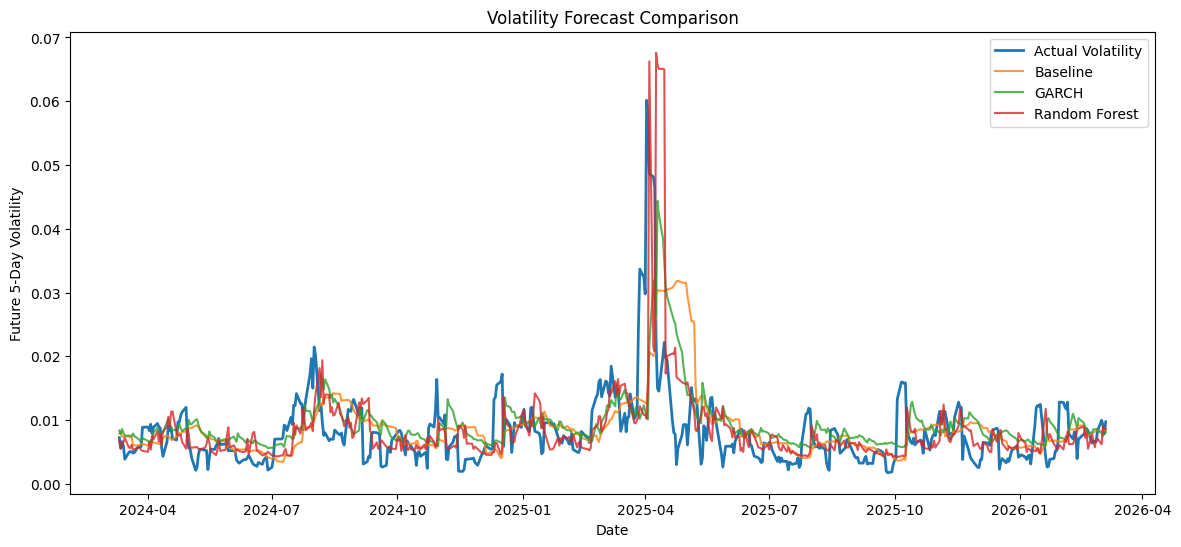

In [30]:
plt.figure(figsize=(14,6))

plt.plot(predictions.index, predictions["actual"], label="Actual Volatility", linewidth=2)
plt.plot(predictions.index, predictions["baseline"], label="Baseline", alpha=0.8)
plt.plot(predictions.index, predictions["garch"], label="GARCH", alpha=0.8)
plt.plot(predictions.index, predictions["random_forest"], label="Random Forest", alpha=0.8)

plt.title("Volatility Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Future 5-Day Volatility")
plt.legend()

plt.show()

In [31]:
errors = pd.DataFrame({
    "Baseline": abs(predictions["actual"] - predictions["baseline"]),
    "GARCH": abs(predictions["actual"] - predictions["garch"]),
    "Random Forest": abs(predictions["actual"] - predictions["random_forest"])
})

errors.mean()

Baseline         0.003937
GARCH            0.003899
Random Forest    0.003631
dtype: float64

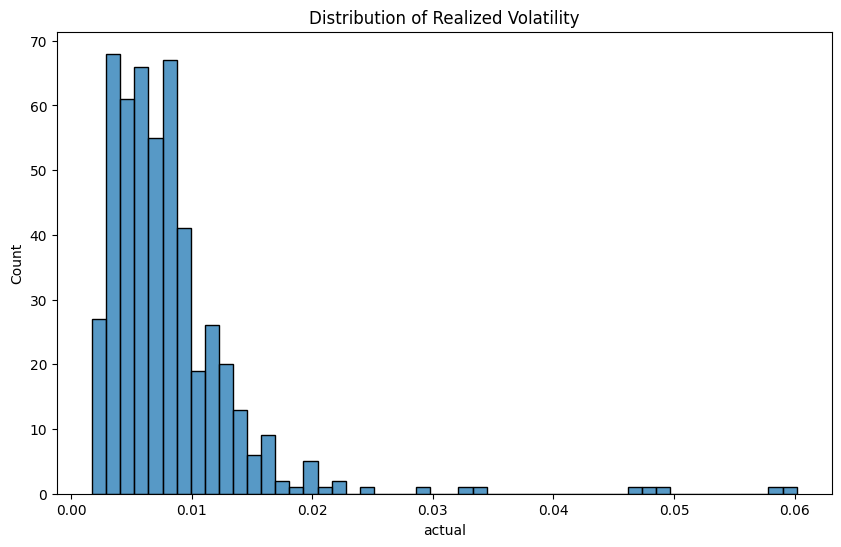

In [32]:
plt.figure(figsize=(10,6))

sns.histplot(predictions["actual"], bins=50)

plt.title("Distribution of Realized Volatility")
plt.show()

In [33]:
high_vol = predictions[predictions["actual"] > predictions["actual"].quantile(0.9)]

high_vol.head()

,actual,baseline,garch,random_forest
Date,,,,
2024-07-19,0.014146,0.006142,0.008779,0.009168
2024-07-26,0.013402,0.008889,0.011468,0.008414
2024-07-29,0.017235,0.008844,0.011393,0.009128
2024-07-30,0.019628,0.008889,0.010397,0.009595
2024-07-31,0.015008,0.009490,0.009743,0.008289
